In [1]:
import numpy as np
from sklearn.neural_network import MLPRegressor
from ipso import pso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd
from keras.models import Sequential
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from keras.layers import Dense
from tensorflow import keras
from tensorflow.keras import layers
#from PSOOptimizer import PSOOptimizer

In [2]:
data = pd.read_excel('./data/data.xlsx')

# 提取输入特征和输出标签
#X = data[['外侧干球','压缩机频率','风机频率','冷媒压力2#排气','冷媒压力3#喷焓','冷媒压力4#回气','T3','冷中','辅进','冷媒散热管出口','辅出']]
X = data[['压缩机频率','风机频率','排气','T3','辅进','辅出']]
Y = data[['能力','能效','热回流率']]
# 数据标准化
scaler = StandardScaler()
x = scaler.fit_transform(X)
y = scaler.fit_transform(Y)
# 划分数据集为训练集、验证集和测试集
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [3]:
# 创建神经网络模型
model = keras.Sequential([
    layers.Dense(5, activation='relu',input_shape=(X_train.shape[1],)),
    layers.Dense(y_train.shape[1])  # 2是输出的维度，对应能力和能效
])

In [4]:
# 定义 PSO 优化器
#optimizer = PSOOptimizer(num_particles=10, c1=2.0, c2=2.0, w_min=0.4, w_max=0.9)

In [5]:
model.compile(optimizer="adam", loss='mean_squared_error')

# 训练模型
history=model.fit(X_train, y_train, epochs=1000, batch_size=32)

# 评估模型
loss = model.evaluate(X_test, y_test)
print(f'Test loss: {loss}')

# 使用模型进行预测
prediction = model.predict(X_test)

# 如果需要，将预测结果反标准化回原始范围
predictions = scaler.inverse_transform(prediction)


Epoch 1/1000

33/33 [==============================] - 3s 5ms/step - loss: 1.4240
Epoch 2/1000
33/33 [==============================] - 0s 3ms/step - loss: 1.1835
Epoch 3/1000
33/33 [==============================] - 0s 3ms/step - loss: 1.0021
Epoch 4/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.8566
Epoch 5/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.7365
Epoch 6/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.6344
Epoch 7/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.5487
Epoch 8/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.4816
Epoch 9/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.4274
Epoch 10/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.3864
Epoch 11/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.3549
Epoch 12/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.3306
Epoch 13/1000
33/33 [==

33/33 [==============================] - 0s 3ms/step - loss: 0.1038
Epoch 97/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.1033
Epoch 98/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.1025
Epoch 99/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.1020
Epoch 100/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.1013
Epoch 101/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.1009
Epoch 102/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.1005
Epoch 103/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0998
Epoch 104/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0994
Epoch 105/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0991
Epoch 106/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0985
Epoch 107/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0978
Epoch 108/1000
33/33 [

33/33 [==============================] - 0s 3ms/step - loss: 0.0834
Epoch 195/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0835
Epoch 196/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0832
Epoch 197/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0832
Epoch 198/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0829
Epoch 199/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0830
Epoch 200/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0829
Epoch 201/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0831
Epoch 202/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0829
Epoch 203/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0829
Epoch 204/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0828
Epoch 205/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0826
Epoch 206/1000
33/3

33/33 [==============================] - 0s 2ms/step - loss: 0.0769
Epoch 293/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0768
Epoch 294/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0766
Epoch 295/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0766
Epoch 296/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0765
Epoch 297/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0763
Epoch 298/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0763
Epoch 299/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0763
Epoch 300/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0762
Epoch 301/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0762
Epoch 302/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0761
Epoch 303/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0762
Epoch 304/1000
33/3

33/33 [==============================] - 0s 3ms/step - loss: 0.0724
Epoch 391/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0723
Epoch 392/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0724
Epoch 393/1000
33/33 [==============================] - 0s 4ms/step - loss: 0.0725
Epoch 394/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0724
Epoch 395/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0726
Epoch 396/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0722
Epoch 397/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0722
Epoch 398/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0721
Epoch 399/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0721
Epoch 400/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0721
Epoch 401/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0721
Epoch 402/1000
33/3

...

33/33 [==============================] - 0s 4ms/step - loss: 0.0666
Epoch 587/1000
33/33 [==============================] - 0s 4ms/step - loss: 0.0664
Epoch 588/1000
33/33 [==============================] - 0s 6ms/step - loss: 0.0665
Epoch 589/1000
33/33 [==============================] - 0s 5ms/step - loss: 0.0665
Epoch 590/1000
33/33 [==============================] - 0s 5ms/step - loss: 0.0665
Epoch 591/1000
33/33 [==============================] - 0s 4ms/step - loss: 0.0664
Epoch 592/1000
33/33 [==============================] - 0s 4ms/step - loss: 0.0664
Epoch 593/1000
33/33 [==============================] - 0s 5ms/step - loss: 0.0664
Epoch 594/1000
33/33 [==============================] - 0s 4ms/step - loss: 0.0665
Epoch 595/1000
33/33 [==============================] - 0s 5ms/step - loss: 0.0663
Epoch 596/1000
33/33 [==============================] - 0s 4ms/step - loss: 0.0663
Epoch 597/1000
33/33 [==============================] - 0s 5ms/step - loss: 0.0667
Epoch 598/1000
33/3

33/33 [==============================] - 0s 3ms/step - loss: 0.0658
Epoch 685/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0651
Epoch 686/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0655
Epoch 687/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0652
Epoch 688/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0654
Epoch 689/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0651
Epoch 690/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0652
Epoch 691/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0652
Epoch 692/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0651
Epoch 693/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0657
Epoch 694/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0652
Epoch 695/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0650
Epoch 696/1000
33/3

33/33 [==============================] - 0s 3ms/step - loss: 0.0643
Epoch 783/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0640
Epoch 784/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0639
Epoch 785/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0638
Epoch 786/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0640
Epoch 787/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0641
Epoch 788/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0640
Epoch 789/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0641
Epoch 790/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0641
Epoch 791/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0640
Epoch 792/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0640
Epoch 793/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0638
Epoch 794/1000
33/3

33/33 [==============================] - 0s 3ms/step - loss: 0.0614
Epoch 881/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0614
Epoch 882/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0612
Epoch 883/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0614
Epoch 884/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0611
Epoch 885/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0610
Epoch 886/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0612
Epoch 887/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0610
Epoch 888/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0611
Epoch 889/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0608
Epoch 890/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0611
Epoch 891/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0608
Epoch 892/1000
33/3

33/33 [==============================] - 0s 2ms/step - loss: 0.0572
Epoch 979/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0569
Epoch 980/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0572
Epoch 981/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0569
Epoch 982/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0569
Epoch 983/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0570
Epoch 984/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0568
Epoch 985/1000
33/33 [==============================] - 0s 3ms/step - loss: 0.0570
Epoch 986/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0568
Epoch 987/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0568
Epoch 988/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0566
Epoch 989/1000
33/33 [==============================] - 0s 2ms/step - loss: 0.0567
Epoch 990/1000
33/3

In [6]:
def r_squared(y_true, y_pred):

    # 计算总平方和（Total Sum of Squares）
    total_sum_of_squares = np.sum((y_true - np.mean(y_true))**2)

    # 计算残差平方和（Residual Sum of Squares）
    residual_sum_of_squares = np.sum((y_true - y_pred)**2)

    # 计算R-squared（决定系数）
    r2 = 1 - (residual_sum_of_squares / total_sum_of_squares)

    return r2


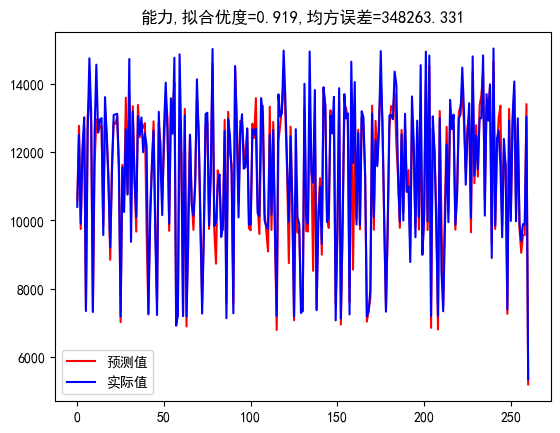

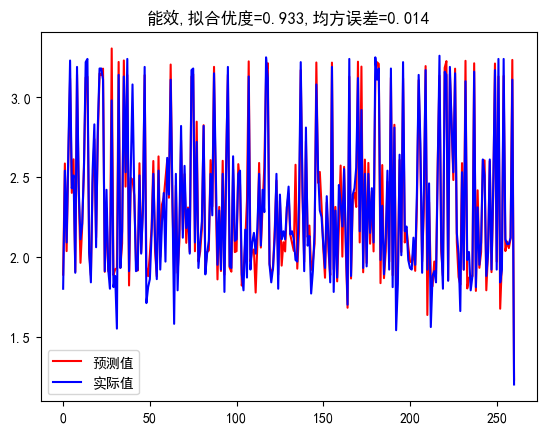

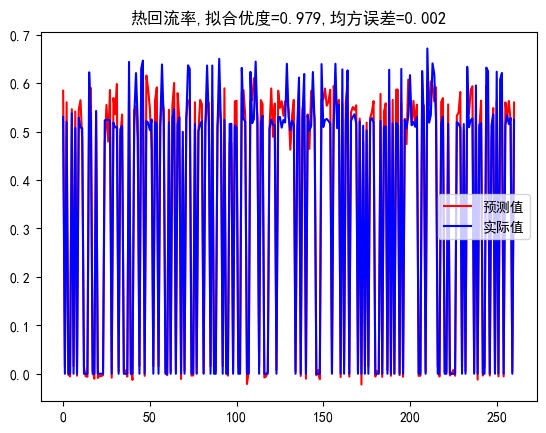

In [7]:
#预测数据索引
index=0
xarry=np.arange(predictions.shape[0])
plt.rcParams['font.family'] = ['SimHei']
plt.plot(xarry,predictions[:,index],label='预测值',c='r')
#恢复测试数据集
Y_data=scaler.inverse_transform(y_test)
r2=r_squared(predictions[:,index],Y_data[:,index])
plt.plot(xarry,Y_data[:,index],label="实际值",c='b')
mse = mean_squared_error(predictions[:,index], Y_data[:,index])
plt.title(Y.columns[index]+',拟合优度={:.3f}'.format(r2)+',均方误差={:.3f}'.format(mse))
plt.legend()
plt.show()

#预测数据索引
index=1
xarry=np.arange(predictions.shape[0])
plt.rcParams['font.family'] = ['SimHei']
plt.plot(xarry,predictions[:,index],label='预测值',c='r')
#恢复测试数据集
Y_data=scaler.inverse_transform(y_test)
r2=r_squared(predictions[:,index],Y_data[:,index])
plt.plot(xarry,Y_data[:,index],label="实际值",c='b')
mse = mean_squared_error(predictions[:,index], Y_data[:,index])
plt.title(Y.columns[index]+',拟合优度={:.3f}'.format(r2)+',均方误差={:.3f}'.format(mse))
plt.legend()
plt.show()

#预测数据索引
index=2
xarry=np.arange(predictions.shape[0])
plt.rcParams['font.family'] = ['SimHei']
plt.plot(xarry,predictions[:,index],label='预测值',c='r')
#恢复测试数据集
Y_data=scaler.inverse_transform(y_test)
r2=r_squared(predictions[:,index],Y_data[:,index])
plt.plot(xarry,Y_data[:,index],label="实际值",c='b')
mse = mean_squared_error(predictions[:,index], Y_data[:,index])
plt.title(Y.columns[index]+',拟合优度={:.3f}'.format(r2)+',均方误差={:.3f}'.format(mse))
plt.legend()
plt.show()

In [ ]:
model.get_weights()